In [187]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

(12, 108, 5994)

In [188]:
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)

In [189]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 10
young_dust_index = -1


#----------------------------
# FSPS no dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_nodust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_diff_dust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse and young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_dusty = sp.get_spectrum(tage=13.8) 

#----------------------------
# FSPS only young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_young_dust = sp.get_spectrum(tage=13.8) 

In [190]:
def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

In [191]:
csp_dusty = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

theta = jnp.array(csp_dusty.theta_init.at[csp_dusty.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dusty.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dusty.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dusty.diffuse_tau_kc_idx].set(diffdust))

spectrum_csp_dusty = run_spectrum_jit(csp_dusty, theta)

theta = jnp.array(csp_dusty.theta_init.at[csp_dusty.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.diffuse_tau_kc_idx].set(0))

spectrum_csp_dusty_dustfree = run_spectrum_jit(csp_dusty, theta)

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha', 'diffuse_tau_kc', 'diffuse_dust_index']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [192]:
csp_diff = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = False, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


theta = jnp.array(csp_diff.theta_init.at[csp_diff.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(diffdust))

spectrum_csp_diff = run_spectrum_jit(csp_diff, theta)

theta = jnp.array(theta.at[csp_diff.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(0))

spectrum_csp_diff_dustfree = run_spectrum_jit(csp_diff, theta)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'diffuse_tau_kc', 'diffuse_dust_index']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'zh_idx'])


In [193]:
csp_young = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

theta = jnp.array(csp_young.theta_init.at[csp_young.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_young.alpha_idx].set(young_dust_index))

spectrum_csp_young = run_spectrum_jit(csp_young, theta)

theta = jnp.array(csp_young.theta_init.at[csp_young.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_young.alpha_idx].set(0))

spectrum_csp_young_dustfree = run_spectrum_jit(csp_young, theta)

Using only binwise dust attenuation.
Initializing Dust attenuation model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [194]:
csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

Using only binwise dust attenuation.
Initializing Dust attenuation model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_61586/3767100620.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


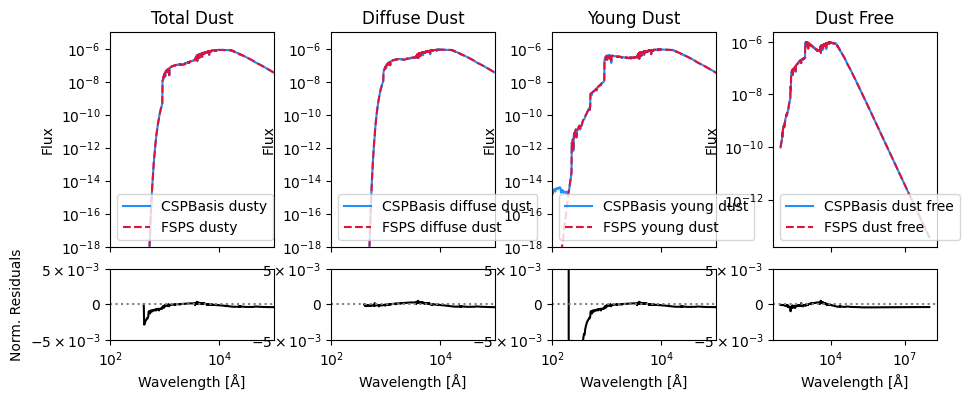

In [195]:
import matplotlib.pyplot as plt
import numpy as np

# Normalized residuals
resid_dusty = (spectrum_csp_dusty - spec_fsps_dusty) / spec_fsps_dusty
resid_diff  = (spectrum_csp_diff - spec_fsps_diff_dust) / spec_fsps_diff_dust
resid_young = (spectrum_csp_young - spec_fsps_young_dust) / spec_fsps_young_dust

# Create figure with 3 columns, 2 rows (main spectra + residuals)
fig, axes = plt.subplots(
    2, 4, figsize=(32/3, 4), sharex='col',
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15, 'wspace': 0.35}
)

axes[0, 0].set_ylim(1e-18, 1e-5)
axes[0, 1].set_ylim(1e-18, 1e-5)
axes[0, 2].set_ylim(1e-18, 1e-5)

axes[0, 0].set_xlim(1e2, 1e5)
axes[0, 1].set_xlim(1e2, 1e5)
axes[0, 2].set_xlim(1e2, 1e5)

# --- Panel 1: total dusty ---
axes[0, 0].loglog(csp.wave, spectrum_csp_dusty, color='dodgerblue', label='CSPBasis dusty')
axes[0, 0].loglog(wave, spec_fsps_dusty, color='crimson', linestyle='--', label='FSPS dusty')
axes[0, 0].set_title('Total Dust')
axes[0, 0].legend()

axes[1, 0].plot(csp.wave, resid_dusty, color='black')
axes[1, 0].axhline(0, color='gray', linestyle=':')
axes[1, 0].set_xlabel('Wavelength [Å]')
axes[1, 0].set_ylabel('Norm. Residuals')

# --- Panel 2: diffuse dust ---
axes[0, 1].loglog(csp.wave, spectrum_csp_diff, color='dodgerblue', label='CSPBasis diffuse dust')
axes[0, 1].loglog(wave, spec_fsps_diff_dust, color='crimson', linestyle='--', label='FSPS diffuse dust')
axes[0, 1].set_title('Diffuse Dust')
axes[0, 1].legend()

axes[1, 1].plot(csp.wave, resid_diff, color='black')
axes[1, 1].axhline(0, color='gray', linestyle=':')
axes[1, 1].set_xlabel('Wavelength [Å]')

# --- Panel 3: young dust ---
axes[0, 2].loglog(csp.wave, spectrum_csp_young, color='dodgerblue', label='CSPBasis young dust')
axes[0, 2].loglog(wave, spec_fsps_young_dust, color='crimson', linestyle='--', label='FSPS young dust')
axes[0, 2].set_title('Young Dust')
axes[0, 2].legend()

axes[1, 2].plot(csp.wave, resid_young, color='black')
axes[1, 2].axhline(0, color='gray', linestyle=':')
axes[1, 2].set_xlabel('Wavelength [Å]')

# --- Panel 4: dust_free ---
axes[0, 3].loglog(csp.wave, spectrum_csp_dusty_dustfree, color='dodgerblue', label='CSPBasis dust free')
axes[0, 3].loglog(wave, spec_fsps_nodust, color='crimson', linestyle='--', label='FSPS dust free')
axes[0, 3].set_title('Dust Free')
axes[0, 3].legend()

axes[1, 3].plot(csp.wave, (spectrum_csp_dusty_dustfree - spec_fsps_nodust) / spec_fsps_nodust, color='black')
axes[1, 3].set_xlabel('Wavelength [Å]')
axes[1, 3].axhline(0, color='gray', linestyle=':')

# --- Shared adjustments ---
for ax in axes[0]:
    ax.set_ylabel('Flux')
for ax in axes[1]:
    ax.set_ylim(-0.005, 0.005)  # adjust if needed
    ax.set_yscale('symlog')

plt.tight_layout()
plt.show()

# Have a purely young population, so that Everything Falls into the Young Bin

In [141]:
T_UNIV = 13.8  # Gyr, age of the universe
N_T = 500     # number of time steps for SFH

t = jnp.linspace(13.8 - 10**(-1.98), T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal_young = gaussian_burst(tau, 1.5,2, 1.0)
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)


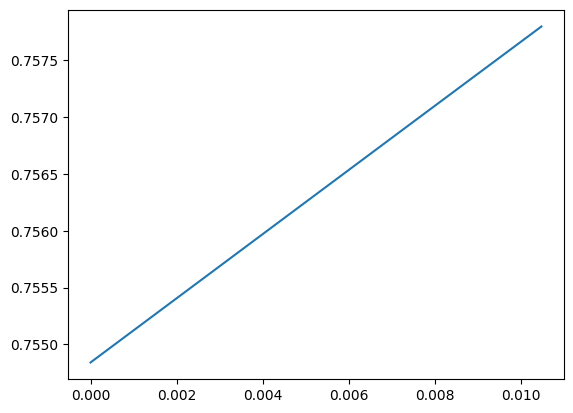

In [142]:
plt.plot(tau, sfr_bimodal_young)

In [143]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal_young), Z=zh)

In [144]:
diffdust = 2.0
diffdust_index = -0.7
young_dust = 10
young_dust_index = -1


#----------------------------
# FSPS no dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_nodust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS only young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_young_dust = sp.get_spectrum(tage=13.8) 

In [145]:
csp_young = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal_young, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.98)], 
                                'laws': ['powerlaw']}, verbose = True)

theta = jnp.array(csp_young.theta_init.at[csp_young.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_young.alpha_idx].set(young_dust_index))

spectrum_csp_young = run_spectrum_jit(csp_young, theta)

theta = jnp.array(csp_young.theta_init.at[csp_young.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_young.alpha_idx].set(0))

spectrum_csp_young_dustfree = run_spectrum_jit(csp_young, theta)

Using only binwise dust attenuation.
Initializing Dust attenuation model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [146]:
10**-1 * 1e9 - 10**-2 * 1e9

90000000.0

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_61586/2893247666.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


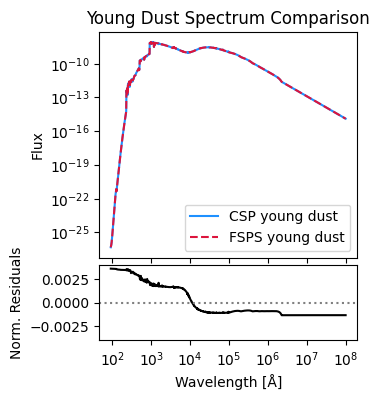

In [147]:
resid_young = (spectrum_csp_young - spec_fsps_young_dust) / spec_fsps_young_dust

# Create figure with two vertically stacked panels
fig, (ax_spec, ax_resid) = plt.subplots(
    2, 1, figsize=(10/3, 4),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
    sharex=True
)

# --- Spectrum comparison (log–log) ---
ax_spec.loglog(wave, spectrum_csp_young, color='dodgerblue', label='CSP young dust')
ax_spec.loglog(wave, spec_fsps_young_dust, color='crimson', linestyle='--', label='FSPS young dust')
ax_spec.set_ylabel("Flux")
ax_spec.legend()
ax_spec.set_title("Young Dust Spectrum Comparison")

# --- Residuals underneath ---
ax_resid.plot(wave, resid_young, color='black')
ax_resid.axhline(0, color='gray', linestyle=':')
ax_resid.set_xlabel("Wavelength [Å]")
ax_resid.set_ylabel("Norm. Residuals")
ax_resid.set_xscale("symlog")  # keep wavelength log-scaled
ax_resid.set_ylim(-0.004, 0.004)  # adjust as needed

plt.tight_layout()
plt.show()

In [120]:
jnp.log10(10**sp.params['dust_tesc']/1e9)

Array(-1.9999999, dtype=float32)

In [11]:
from sedpy_jax.attenuation_dust import ATTENUATION_LAWS

In [15]:
powerlaw = ATTENUATION_LAWS['powerlaw']

In [16]:
powerlaw

{'func': <function sedpy_jax.attenuation_dust.powerlaw(wave, tau_pow=1.0, alpha_pow=1.0, **kwargs)>,
 'params': {'tau_pow': 'Optical depth at reference wavelength (e.g., 1500 Å)',
  'alpha': 'Slope of attenuation power law (typically negative)'},
 'defaults': {'tau_pow': 1.0, 'alpha': 1.0},
 'doc': 'Simple power-law attenuation model used for general testing or toy models.'}

In [17]:
pow = powerlaw['func'](csp.wave, tau_pow=young_dust, alpha = young_dust_index)

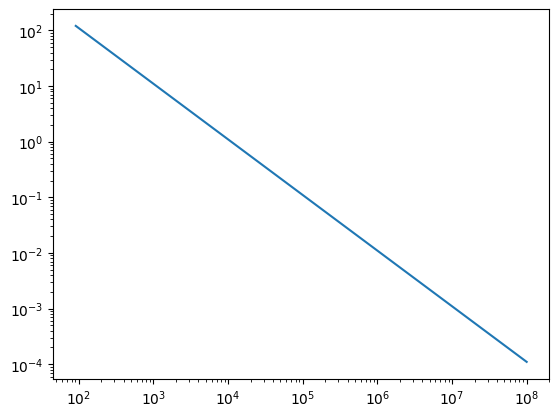

In [19]:
plt.loglog(wave, pow)